# Level scaling

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Parameters

In [2]:
LEVEL_PARAMS = {
    1: {
        'env_width': 3.6,
        'n_grid_segments': 2,
        'n_graph_points': 5,
        'n_bots': 2,
        'n_objects': 2,
        'ep_duration': 10,
        'rng_seed': 12},
    2: {
        'env_width': 5.4,
        'n_grid_segments': 3,
        'n_graph_points': 9,
        'n_bots': 4,
        'n_objects': 3,
        'ep_duration': 30,
        'rng_seed': 42},
    3: {
        'env_width': 9,
        'n_grid_segments': 5,
        'n_graph_points': 16,
        'n_bots': 8,
        'n_objects': 4,
        'ep_duration': 60,
        'rng_seed': 5927},
    4: {
        'env_width': 12.6,
        'n_grid_segments': 7,
        'n_graph_points': 28,
        'n_bots': 16,
        'n_objects': 5,
        'ep_duration': 90,
        'rng_seed': 42},
    5: {
        'env_width': 18,
        'n_grid_segments': 10,
        'n_graph_points': 51,
        'n_bots': 32,
        'n_objects': 6,
        'ep_duration': 150,
        'rng_seed': 50},
    6: {
        'env_width': 25.2,
        'n_grid_segments': 14,
        'n_graph_points': 95,
        'n_bots': 64,
        'n_objects': 7,
        'ep_duration': 240,
        'rng_seed': 1},
    7: {
        'env_width': 36,
        'n_grid_segments': 20,
        'n_graph_points': 181,
        'n_bots': 128,
        'n_objects': 8,
        'ep_duration': 420,
        'rng_seed': 64578}}

## Ratios

In [3]:
xaxis = list(range(1, 8))

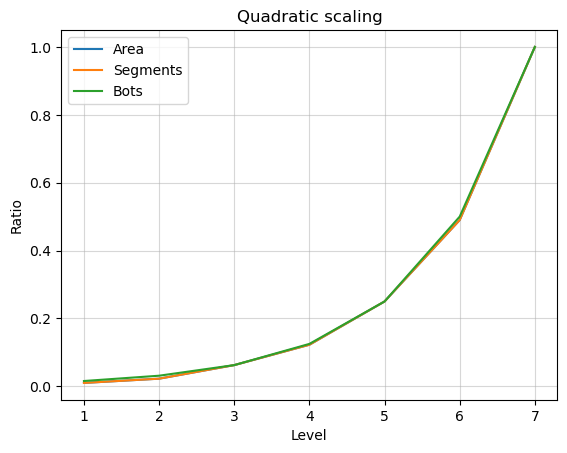

In [4]:
plt.plot(
    xaxis,
    [x['env_width']**2 / LEVEL_PARAMS[7]['env_width']**2 for x in LEVEL_PARAMS.values()],
    label='Area');

plt.plot(
    xaxis,
    [x['n_grid_segments']**2 / LEVEL_PARAMS[7]['n_grid_segments']**2 for x in LEVEL_PARAMS.values()],
    label='Segments');

plt.plot(
    xaxis,
    [x['n_bots'] / LEVEL_PARAMS[7]['n_bots'] for x in LEVEL_PARAMS.values()],
    label='Bots')

plt.xlabel('Level')
plt.ylabel('Ratio')
plt.title('Quadratic scaling')
plt.grid(alpha=0.5)
plt.legend();

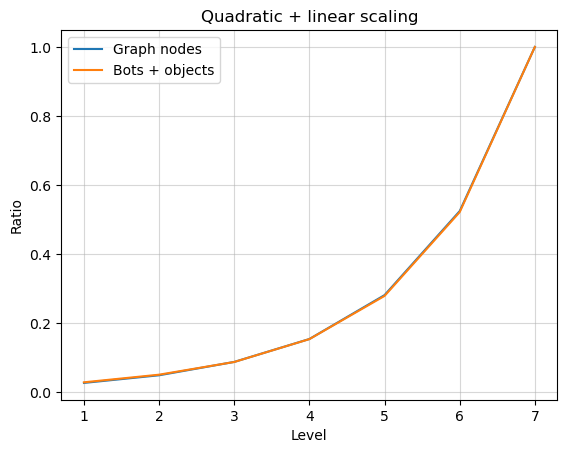

In [5]:
plt.plot(
    xaxis,
    [x['n_graph_points'] / LEVEL_PARAMS[7]['n_graph_points'] for x in LEVEL_PARAMS.values()],
    label='Graph nodes')

plt.plot(
    xaxis,
    [(x['n_bots'] + x['n_objects']) / (LEVEL_PARAMS[7]['n_bots'] + LEVEL_PARAMS[7]['n_objects']) for x in LEVEL_PARAMS.values()],
    label='Bots + objects')

plt.xlabel('Level')
plt.ylabel('Ratio')
plt.title('Quadratic + linear scaling')
plt.grid(alpha=0.5)
plt.legend();

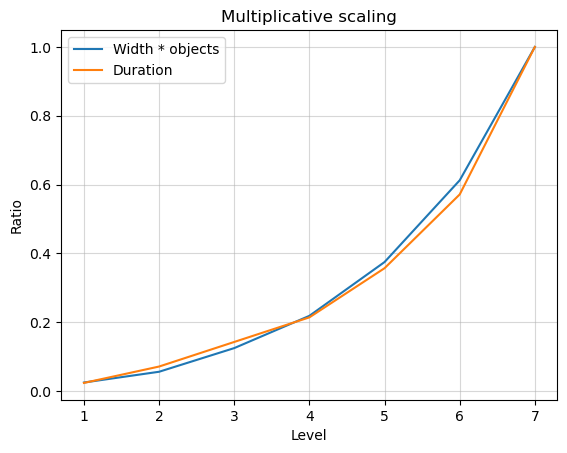

In [6]:
plt.plot(
    xaxis,
    [x['env_width'] * x['n_objects'] / (LEVEL_PARAMS[7]['env_width'] * LEVEL_PARAMS[7]['n_objects']) for x in LEVEL_PARAMS.values()],
    label='Width * objects');

plt.plot(
    xaxis,
    [x['ep_duration'] / LEVEL_PARAMS[7]['ep_duration'] for x in LEVEL_PARAMS.values()],
    label='Duration')

plt.xlabel('Level')
plt.ylabel('Ratio')
plt.title('Multiplicative scaling')
plt.grid(alpha=0.5)
plt.legend();

## Experimental

In [7]:
throughput = np.array([1.5047, 1.3005, 0.6312, 0.6971, 0.4440, 0.2778, 0.2851])
goals_reached = throughput * np.array([LEVEL_PARAMS[i]['ep_duration'] for i in range(1, 8)]) / 10
contact_penalty = np.array([0.1/i * LEVEL_PARAMS[i]['ep_duration'] for i in range(1, 8)]) * 4

penalty_to_reward = contact_penalty / goals_reached
avg_penalty_to_reward = np.mean(penalty_to_reward)

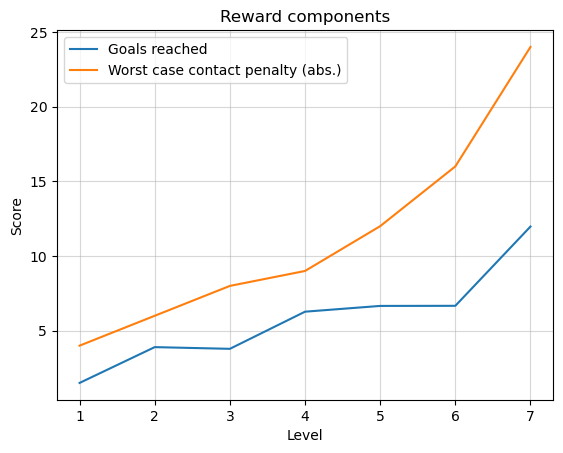

In [8]:
plt.plot(xaxis, goals_reached, label='Goals reached')
plt.plot(xaxis, contact_penalty, label='Worst case contact penalty (abs.)');

plt.xlabel('Level')
plt.ylabel('Score')
plt.title('Reward components')
plt.grid(alpha=0.5)
plt.legend();

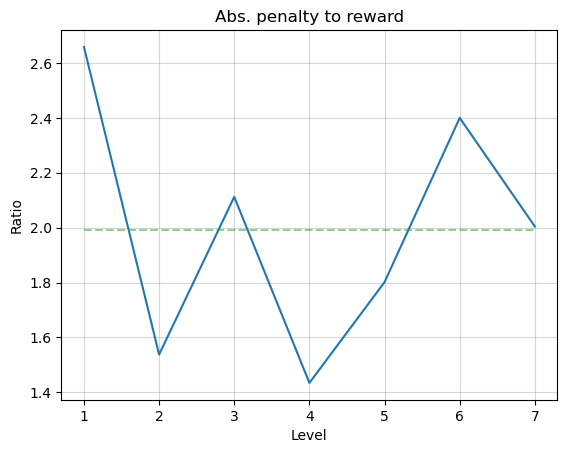

In [9]:
plt.plot(xaxis, penalty_to_reward);
plt.plot(xaxis, [avg_penalty_to_reward]*len(xaxis), 'C2--', alpha=0.5)

plt.xlabel('Level')
plt.ylabel('Ratio')
plt.title('Abs. penalty to reward')
plt.grid(alpha=0.5);